# Cushing inventory and the WTI curve

**Yuang Zuo — reproducible research walkthrough**

How does inventory relative to seasonal history relate to the curve, and where does that relationship break down?

This notebook reads the same real-data result used by the HTML/PDF. It distinguishes descriptive association, the post-review D1/D2 mechanism exploration, and the original B0–B3 forecasting/trading question. The latter remains untested until actual monthly contract data passes acceptance. No synthetic observations enter this notebook.

Run `build --offline` before executing. Each result's own manifest supplies its version; no run ID is hardcoded here.

In [1]:
from pathlib import Path
import json
import pandas as pd
try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value.to_string(index=False) if isinstance(value, pd.DataFrame) else value)
from cushing_research.pipeline import make_manifest
from cushing_research.snapshot import verify_snapshot

root = Path.cwd()
if not (root / 'config/research.json').is_file():
    raise RuntimeError('Use the project directory as the notebook working directory.')
result = json.loads((root / 'outputs/results.json').read_text())
config = result['config']
if make_manifest(root, config)['run_id'] != result['run_id']:
    raise RuntimeError('Saved results are stale. Run build --offline, then restart this notebook.')
snapshot = verify_snapshot(root)
print('Evidence state:', result['status'])
print('Result version:', result['run_id'])
print('Data cutoff:', result['data_cutoff'])
print(result['conclusion'])

Evidence state: public_evidence_only
Result version: 902e770aeb2ecdab
Data cutoff: 2026-09-14
Across 481 publication observations, the median F2-F3 quote is +0.37 USD/bbl in low-inventory states and -0.62 in high-inventory states (rank correlation -0.73). This historical association varies across years. The exploratory joint test does not provide sufficient evidence of a shape difference beyond the linear controlled relationship. Actual monthly contract data is still required to test incremental forecasting value and trading costs.


## 1. Check what was published and which files support it

The observation week, actual release date and New York end-of-day cutoff are different fields. A complete snapshot is determined by the **expected source graph**, not by whichever files remain on disk. Every cited raw file, sidecar, audit checksum and processed source link must agree.

The later historical cross-check is diagnostic: it does not overwrite original publication values or become a past decision input.

In [2]:
print(json.dumps(snapshot, indent=2))
inventory = pd.read_csv(root / 'data/processed/inventory.csv')
inventory = inventory.loc[inventory.release_date.between(config['warmup_start'], config['data_cutoff'])]
display(inventory[['report_id', 'week_ending', 'release_date', 'knowledge_cutoff',
                   'cushing_mbbl', 'source_url', 'sha256']].tail(8))
print('Original reports:', len(inventory), 'Distinct release days:', inventory.release_date.nunique())
source_audit = result['data_audit']['inventory']
display(pd.DataFrame(source_audit.get('supporting_sources', [])))

{
  "status": "complete",
  "mode": "offline_sha256",
  "expected_raw_files": 801,
  "verified_raw_files": 801,
  "verified_processed_files": 3,
  "processed_files": [
    "data/processed/inventory.csv",
    "data/processed/public_futures.csv",
    "data/processed/inventory_latest_crosscheck.csv"
  ],
  "inventory_source_links": 789,
  "public_futures_source_ranks": [
    "F1",
    "F2",
    "F3",
    "F4"
  ],
  "required_source_rule": "Processed audits determine expected sources; each raw file and sidecar must agree with its audit checksum and URL",
  "limitation": "Local snapshot consistency does not prove publisher files were immutable since first release"
}


report_id,week_ending,release_date,knowledge_cutoff,cushing_mbbl,source_url,sha256
2026_07_22,2026-07-17,2026-07-22,2026-07-23T03:59:59+00:00,19.370,https://www.eia.gov/petroleum/supply/weekly/archive/2026/2026_07_22/csv/table9.csv,9d79cdd2860521a7c1382eb443c73e1ee39909cdf1a4c8f9f63d1c263da762e0
2026_07_29,2026-07-24,2026-07-29,2026-07-30T03:59:59+00:00,18.599,https://www.eia.gov/petroleum/supply/weekly/archive/2026/2026_07_29/csv/table9.csv,737fc140ac01733f0b57453cf3ab670481699f01b9150ea31f1995ce0b431e36
2026_08_05,2026-07-31,2026-08-05,2026-08-06T03:59:59+00:00,20.955,https://www.eia.gov/petroleum/supply/weekly/archive/2026/2026_08_05/csv/table9.csv,6c47ddb026eb70c161d6830cd59f654e6724eaf6ac00a63cfce1c59f53404893
2026_08_12,2026-08-07,2026-08-12,2026-08-13T03:59:59+00:00,22.566,https://www.eia.gov/petroleum/supply/weekly/archive/2026/2026_08_12/csv/table9.csv,229967c8383fb38fc77f19a455d6a775429ce57929bd588e70588ec695ceea47
2026_08_19,2026-08-14,2026-08-19,2026-08-20T03:59:59+00:00,21.252,https://www.eia.gov/petroleum/supply/weekly/archive/2026/2026_08_19/csv/table9.csv,b3e50b7bf1f49f29536a4ca2711a335d0645abdb8c0584840073372488f8acf3
2026_08_26,2026-08-21,2026-08-26,2026-08-27T03:59:59+00:00,22.428,https://www.eia.gov/petroleum/supply/weekly/archive/2026/2026_08_26/csv/table9.csv,8353466069baccd3b5d1283bf365120bb51a5b16329620faccf1fb78f597c350
2026_09_02,2026-08-28,2026-09-02,2026-09-03T03:59:59+00:00,22.508,https://www.eia.gov/petroleum/supply/weekly/archive/2026/2026_09_02/csv/table9.csv,732378304a986fe6c44c680ac48fcc268005c7a8ef3fe00ff8e686d55bdddf1e
2026_09_10,2026-09-04,2026-09-10,2026-09-11T03:59:59+00:00,21.824,https://www.eia.gov/petroleum/supply/weekly/archive/2026/2026_09_10/csv/table9.csv,2cca190aac8536edea506915fba55811923f735c640019a0bcc948c58e502fbe


Original reports: 789 Distinct release days: 787


url,resolved_url,sha256,downloaded_at_utc,bytes,prior_attempt_errors,raw_file,report_id,purpose,passed
https://www.eia.gov/petroleum/supply/weekly/archive/2020/2020_03_18/csv/table4.csv,https://www.eia.gov/petroleum/supply/weekly/archive/2020/2020_03_18/csv/table4.csv,084de71b41d3721ea2c3faf8f1aacd4f1cb3c08e8ddb66da9e47a3f0dce343de,2026-09-15T02:25:29+00:00,2330,[],data/raw/inventory/2020_03_18_table4.csv,2020_03_18,Same-release crude-total rounding reconciliation; stocks match Table 9,True
https://www.eia.gov/petroleum/supply/weekly/archive/2020/2020_04_15/csv/table4.csv,https://www.eia.gov/petroleum/supply/weekly/archive/2020/2020_04_15/csv/table4.csv,ca5b0a93bc4d1fe6b257b75625c1a72b77f798c17a9dcbc576757ecbfdfce083,2026-09-15T02:25:28+00:00,2320,[],data/raw/inventory/2020_04_15_table4.csv,2020_04_15,Same-release crude-total rounding reconciliation; stocks match Table 9,True


## 2. Reconstruct the historical information set

The module admits only inventory observations already published at each cutoff. For the z-score, it uses the previous three calendar years within ±28 circular seasonal days, at least 20 observations and sample standard deviation. Low is z < −1; High is z > +1; boundary values are Normal.

This is a seasonal anomaly, **not** uncommitted capacity or an operating floor. Same-day reports enter together; the latest observation week defines the single decision. One/four-week changes look up the exact earlier observation weeks.

In [3]:
from cushing_research.features import inventory_features
features = inventory_features(inventory, config)
stored_features = pd.DataFrame(result['inventory'])
check_columns = ['release_date', 'week_ending', 'inv_z', 'inv_delta1', 'inv_delta4', 'inv_reference_n', 'state']
pd.testing.assert_frame_equal(features[check_columns].reset_index(drop=True),
                              stored_features[check_columns].reset_index(drop=True),
                              check_dtype=False, check_exact=False, rtol=1e-12, atol=1e-12)
display(features[['release_date', 'week_ending', 'reports_on_release_date',
                  'inv_reference_n', 'inv_reference_mean', 'inv_reference_std',
                  'inv_z', 'inv_delta1', 'inv_delta4', 'state']].tail(8))
print('Historical feature reconstruction agrees with the saved result.')

release_date,week_ending,reports_on_release_date,inv_reference_n,inv_reference_mean,inv_reference_std,inv_z,inv_delta1,inv_delta4,state
2026-07-22,2026-07-17,1,24,30.612708,7.188115,-1.564069,-0.674,0.413,Low
2026-07-29,2026-07-24,1,24,29.903500,6.568829,-1.720931,-0.771,-1.067,Low
2026-08-05,2026-07-31,1,24,29.133375,5.774098,-1.416390,2.356,1.341,Low
2026-08-12,2026-08-07,1,24,28.385792,4.930017,-1.180481,1.611,2.522,Low
2026-08-19,2026-08-14,1,24,27.597958,4.292322,-1.478444,-1.314,1.882,Low
2026-08-26,2026-08-21,1,24,26.790250,3.955697,-1.102777,1.176,3.829,Low
2026-09-02,2026-08-28,1,24,26.025250,3.658067,-0.961505,0.080,1.553,Normal
2026-09-10,2026-09-04,1,24,25.239833,3.077655,-1.109882,-0.684,-0.742,Low


Historical feature reconstruction agrees with the saved result.


## 3. Understand the public pairing before interpreting a correlation

The matched quote is **earlier than** the inventory publication. F2−F3 is a delivery-rank level, not the return on a fixed pair of held contracts. The pooled and annual correlations describe those historical market states; they do not measure a release response or a forecasting edge.

IQR is the distribution's middle half, not a confidence interval. 2024 is a partial year.

In [4]:
public = pd.DataFrame(result['public_observations'])
assert (pd.to_datetime(public.price_date) < pd.to_datetime(public.decision_date)).all()
print('Matched releases:', len(public), 'from', public.decision_date.min(), 'to', public.decision_date.max())
display(public[['decision_date', 'price_date', 'week_ending', 'inv_z', 'state', 'F2', 'F3', 'spread']].tail(8))
display(pd.DataFrame(result['descriptive']['regimes']))
display(pd.DataFrame(result['descriptive']['yearly']))

Matched releases: 481 from 2015-01-07 to 2024-04-03


decision_date,price_date,week_ending,inv_z,state,F2,F3,spread
2024-02-14,2024-02-13,2024-02-09,-0.975849,Normal,77.56,77.24,0.32
2024-02-22,2024-02-21,2024-02-16,-0.860336,Normal,77.31,76.78,0.53
2024-02-28,2024-02-27,2024-02-23,-0.662294,Normal,78.23,77.64,0.59
2024-03-06,2024-03-05,2024-03-01,-0.531532,Normal,77.41,76.82,0.59
2024-03-13,2024-03-12,2024-03-08,-0.518303,Normal,77.25,76.90,0.35
2024-03-20,2024-03-19,2024-03-15,-0.502471,Normal,82.73,82.08,0.65
2024-03-27,2024-03-26,2024-03-22,-0.262004,Normal,81.04,80.43,0.61
2024-04-03,2024-04-02,2024-03-29,-0.290105,Normal,84.22,83.29,0.93


state,n,median_spread,q25,q75,mean_spread
Low,133,0.370,0.1900,1.31,0.788195
Normal,208,-0.025,-0.2400,0.27,-0.087212
High,140,-0.615,-0.8525,-0.37,-0.645429


year,n,spearman
2015,52,-0.177262
2016,52,-0.612652
2017,52,-0.632876
2018,52,-0.479100
2019,52,0.079336
2020,53,-0.227241
2021,52,-0.593113
2022,51,-0.760181
2023,51,-0.422675
2024,14,0.154185


## 4. Read the extension's evidence status and common sample

D1/D2 is a **post-review exploratory extension**. The pooled summaries were already known; the history is not an unseen test set. The frozen specification is in `docs/MECHANISM_EXTENSION.md` and `config/mechanism.json`. The core fit, HAC and bootstrap calculations run in `cushing_research.mechanism.analyze_mechanism` during `build`; this notebook inspects the saved shared result.

D1 explains the preceding spread level with inventory z, release-year intercepts and seasonal terms. D2 adds fixed hinges at −1 and +1. The no-year-control versions retain seasonality. Every model uses the same eligible rows; no knots are optimized.

In [5]:
mechanism = result['mechanism']
print('Mechanism status:', mechanism['status'])
print('Evidence identity:', mechanism['protocol']['evidence_status'])
print('Frozen method:', mechanism['protocol']['protocol_version'])
print('Configuration hash:', mechanism['protocol']['config_sha256'])
print(json.dumps(mechanism['sample'], indent=2))
print('Exclusions:', len(mechanism['exclusions']))
if mechanism['exclusions']:
    display(pd.DataFrame(mechanism['exclusions']))

Mechanism status: complete_exploration
Evidence identity: post-review exploratory extension; not preregistered
Frozen method: mechanism-exploration-v1
Configuration hash: 015fb00efa603d5773df8a8dd707d4630aeac4a28f620c1c0f2f85cc6c94f459
{
  "input_n": 481,
  "n": 481,
  "excluded_n": 0,
  "start": "2015-01-07",
  "end": "2024-04-03",
  "years": [
    2015,
    2016,
    2017,
    2018,
    2019,
    2020,
    2021,
    2022,
    2023,
    2024
  ],
  "tail_support": {
    "Low": {
      "n": 133,
      "years": [
        2018,
        2019,
        2020,
        2021,
        2022,
        2023,
        2024
      ],
      "years_n": 7,
      "inference_eligible": true,
      "reason": null
    },
    "Normal": {
      "n": 208,
      "years": [
        2015,
        2017,
        2018,
        2019,
        2020,
        2021,
        2022,
        2023,
        2024
      ],
      "years_n": 9,
      "inference_eligible": true,
      "reason": null
    },
    "High": {
      "n": 140,

## 5. Compare D1/D2 without confusing fit with prediction

The main exploratory test asks whether **both hinge coefficients are zero** after year/season controls. It uses an eight-release-lag Bartlett HAC covariance, small-sample correction and a two-restriction chi-square Wald test.

Keep the no-year-control result beside it. Year indicators change which variation identifies the relationship; they do not prove the physical mechanism. In-sample error reductions describe fit only and cannot establish H2 or H3.

In [6]:
model_rows = []
for name, model in mechanism['models'].items():
    joint = model.get('joint_test', {})
    model_rows.append({'model': name, 'status': model['status'], 'n': model['n'],
                       'year_controls': model['year_fixed_effects'],
                       'in_sample_MAE': model.get('in_sample_mae'),
                       'joint_hinge_p': joint.get('p_value'), 'test_status': joint.get('status')})
display(pd.DataFrame(model_rows))
print('Main exploratory test:')
print(json.dumps(mechanism['main_test'], indent=2))
print('Main and no-year-control p-values:', mechanism['main_test'].get('p_value'),
      mechanism['models']['D2_no_year_fe'].get('joint_test', {}).get('p_value'))
print(json.dumps(mechanism['conclusion'], indent=2))

model,status,n,year_controls,in_sample_MAE,joint_hinge_p,test_status
D1,available,481,True,0.353465,NaN,None
D2,available,481,True,0.354415,7.753080e-01,available
D1_no_year_fe,available,481,False,0.513962,NaN,None
D2_no_year_fe,available,481,False,0.444156,2.900895e-07,available


Main exploratory test:
{
  "null": "low_hinge = high_hinge = 0",
  "distribution": "chi-square",
  "df": 2,
  "statistic": 0.5089897737744423,
  "p_value": 0.775308017317966,
  "covariance": "HAC Bartlett, 8 release cycles; n/(n-k)",
  "status": "available",
  "reason": null,
  "comparison": "D2 versus D1, common sample with year/season controls",
  "evidence_status": "post-review exploratory extension; not preregistered"
}
Main and no-year-control p-values: 0.775308017317966 2.9008952602011894e-07
{
  "category": "insufficient_nonlinearity_evidence",
  "finding": "The exploratory joint test does not provide sufficient evidence of a shape difference beyond the linear controlled relationship.",
  "limitations": [
    "Analysis was specified after reviewing pooled and annual summaries.",
    "Inventory is matched to a preceding quote; the analysis is neither a release-response nor forecasting test.",
    "Year controls and short blocks cannot eliminate structural change or identify a phy

## 6. Inspect the shape and its uncertainty

The conditional curves hold year/season controls at their common-sample means. The adjusted observations remove their D2 year/season contribution and restore its mean. This plot is a model-adjusted association, not a raw quote forecast.

The main intervals refit each model in 2,000 eight-release moving-block samples. Low/High tail inference requires at least 20 observations across three years. Failures and valid refit counts remain visible. Check blocks 4 and 13 as well; never choose whichever interval looks most favorable.

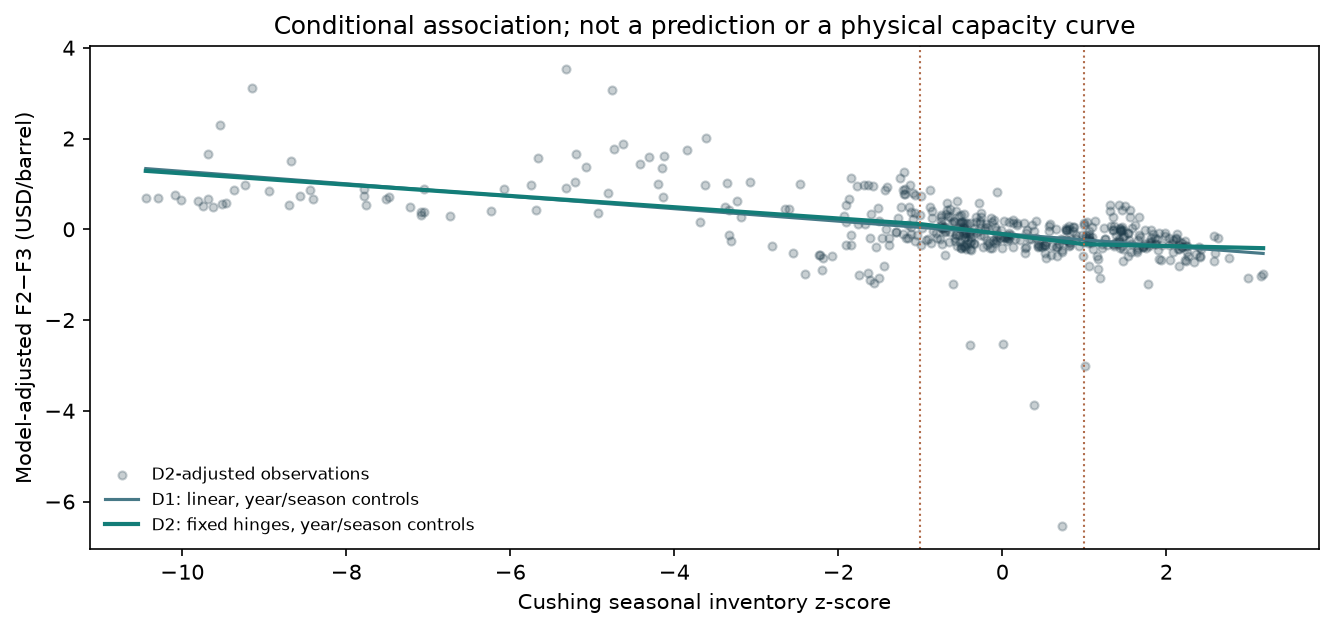

In [7]:
import matplotlib.pyplot as plt
records = pd.DataFrame(mechanism['records'])
curves = pd.DataFrame(mechanism['curves'])
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.scatter(records.inv_z, records.adjusted_spread, s=15, alpha=.24, color='#193746', label='D2-adjusted observations')
ax.plot(curves.z, curves.D1, color='#477987', label='D1: linear, year/season controls')
ax.plot(curves.z, curves.D2, color='#137D78', linewidth=2, label='D2: fixed hinges, year/season controls')
for knot in [-1, 1]:
    ax.axvline(knot, color='#B06B4A', linestyle=':', linewidth=1)
ax.set(xlabel='Cushing seasonal inventory z-score', ylabel='Model-adjusted F2−F3 (USD/barrel)',
       title='Conditional association; not a prediction or a physical capacity curve')
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

In [8]:
slope_rows, refit_rows, change_rows = [], [], []
for block, sample in mechanism['bootstrap'].items():
    for name in ['D1', 'D2']:
        model = sample['models'][name]
        refit_rows.append({'block': int(block), 'model': name,
                          'valid': model['valid_repetitions'], 'invalid': model['invalid_repetitions'],
                          'failure_reasons': model['failure_reasons']})
        for state, row in model['slopes'].items():
            slope_rows.append({'block': int(block), 'model': name, 'state': state,
                               'slope': row.get('estimate'), 'CI_low': row.get('ci_lower'),
                               'CI_high': row.get('ci_upper'), 'status': row['status']})
    for name, row in sample['models']['D2'].get('slope_changes', {}).items():
        change_rows.append({'block': int(block), 'slope_change': name,
                           'CI_low': row.get('ci_lower'), 'CI_high': row.get('ci_upper'), 'status': row['status']})
slopes = pd.DataFrame(slope_rows)
display(slopes.loc[(slopes.block == 8) | (slopes.model == 'D2')].reset_index(drop=True))
display(pd.DataFrame(change_rows))
display(pd.DataFrame(refit_rows))
print('Slope units: USD/barrel per one z unit; zero-crossing intervals do not establish a directional segment slope.')

block,model,state,slope,CI_low,CI_high,status
8,D1,Low,-0.137273,-0.339054,-0.036083,available
8,D1,Normal,-0.137273,-0.339054,-0.036083,available
8,D1,High,-0.137273,-0.339054,-0.036083,available
8,D2,Low,-0.124175,-0.476959,0.001099,available
8,D2,Normal,-0.221109,-0.609232,0.019017,available
8,D2,High,-0.040495,-0.397994,0.391119,available
4,D2,Low,-0.124175,-0.329732,-0.022866,available
4,D2,Normal,-0.221109,-0.519469,0.008473,available
4,D2,High,-0.040495,-0.326677,0.313738,available
13,D2,Low,-0.124175,-0.582091,0.022301,available


block,slope_change,CI_low,CI_high,status
8,Low_minus_Normal,-0.357431,0.516759,available
8,High_minus_Normal,-0.300552,0.827345,available
4,Low_minus_Normal,-0.226955,0.416983,available
4,High_minus_Normal,-0.270603,0.741135,available
13,Low_minus_Normal,-0.447256,0.726637,available
13,High_minus_Normal,-0.338767,1.030034,available


block,model,valid,invalid,failure_reasons
8,D1,2000,0,{}
8,D2,2000,0,{}
4,D1,2000,0,{}
4,D2,2000,0,{}
13,D1,2000,0,{}
13,D2,2000,0,{}


Slope units: USD/barrel per one z unit; zero-crossing intervals do not establish a directional segment slope.


## 7. Keep annual and deleted-year exceptions visible

Annual fits are descriptive; a year lacking a state may not identify both hinges. A missing annual fit is retained with a reason, rather than made finite. The three-year tail support requirement is not an annual significance test.

The deleted-year table is a sensitivity analysis. Removing 2018 changes the shape conclusion; it must not be hidden or used to select a preferred sample. Excluding 2020 is a separate named check. Original release-cycle gaps are retained in HAC after deleting a year.

In [9]:
annual_rows = []
for row in mechanism['annual']:
    model = row['models']['D2']
    annual_rows.append({'year': row['year'], 'n': row['n'], 'partial_year': row['partial_year'],
                        'spearman': row['spearman'], 'state_counts': row['state_counts'],
                        'D2_status': model['status'], 'D2_reason': model.get('reason'),
                        'D2_slopes': {state: value.get('estimate') for state, value in model.get('slopes', {}).items()}})
display(pd.DataFrame(annual_rows))
deletion_rows = []
for row in mechanism['leave_one_year_out']:
    test = row['main_test']
    deletion_rows.append({'excluded_year': row['excluded_year'], 'n': row['n'],
                          'joint_hinge_p': test.get('p_value'), 'test_status': test['status'],
                          'test_reason': test.get('reason'), 'tail_support': row['tail_support'],
                          'hac_gap_policy': row['hac_gap_policy']})
deletions = pd.DataFrame(deletion_rows)
display(deletions)
print('Do not omit these two checks:')
display(deletions.loc[deletions.excluded_year.isin([2018, 2020])])

year,n,partial_year,spearman,state_counts,D2_status,D2_reason,D2_slopes
2015,52,False,-0.177262,"{'Low': 0, 'Normal': 7, 'High': 45}",unavailable,rank_deficient_design,{}
2016,52,False,-0.612652,"{'Low': 0, 'Normal': 0, 'High': 52}",unavailable,rank_deficient_design,{}
2017,52,False,-0.632876,"{'Low': 0, 'Normal': 32, 'High': 20}",unavailable,rank_deficient_design,{}
2018,52,False,-0.479100,"{'Low': 50, 'Normal': 2, 'High': 0}",unavailable,rank_deficient_design,{}
2019,52,False,0.079336,"{'Low': 8, 'Normal': 44, 'High': 0}",unavailable,rank_deficient_design,{}
2020,53,False,-0.227241,"{'Low': 4, 'Normal': 37, 'High': 12}",available,None,"{'Low': 1.0028194330577254, 'Normal': -1.7543439096447129, 'High': 4.307387265341116}"
2021,52,False,-0.593113,"{'Low': 11, 'Normal': 30, 'High': 11}",available,None,"{'Low': -0.7756445462793462, 'Normal': -0.01428025866854693, 'High': 0.11740130894151737}"
2022,51,False,-0.760181,"{'Low': 49, 'Normal': 2, 'High': 0}",unavailable,rank_deficient_design,{}
2023,51,False,-0.422675,"{'Low': 9, 'Normal': 42, 'High': 0}",unavailable,rank_deficient_design,{}
2024,14,True,0.154185,"{'Low': 2, 'Normal': 12, 'High': 0}",unavailable,rank_deficient_design,{}


excluded_year,n,joint_hinge_p,test_status,test_reason,tail_support,hac_gap_policy
2015,429,0.871756,available,None,"{'Low': {'n': 133, 'years': [2018, 2019, 2020, 2021, 2022, 2023, 2024], 'years_n': 7, 'inference_eligible': True, 'reason': None}, 'Normal': {'n': 201, 'years': [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024], 'years_n': 8, 'inference_eligible': True, 'reason': None}, 'High': {'n': 95, 'years': [2016, 2017, 2020, 2021], 'years_n': 4, 'inference_eligible': True, 'reason': None}}",Original release-cycle indices retained; removed-year gap not compressed
2016,429,0.118637,available,None,"{'Low': {'n': 133, 'years': [2018, 2019, 2020, 2021, 2022, 2023, 2024], 'years_n': 7, 'inference_eligible': True, 'reason': None}, 'Normal': {'n': 208, 'years': [2015, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024], 'years_n': 9, 'inference_eligible': True, 'reason': None}, 'High': {'n': 88, 'years': [2015, 2017, 2020, 2021], 'years_n': 4, 'inference_eligible': True, 'reason': None}}",Original release-cycle indices retained; removed-year gap not compressed
2017,429,0.704749,available,None,"{'Low': {'n': 133, 'years': [2018, 2019, 2020, 2021, 2022, 2023, 2024], 'years_n': 7, 'inference_eligible': True, 'reason': None}, 'Normal': {'n': 176, 'years': [2015, 2018, 2019, 2020, 2021, 2022, 2023, 2024], 'years_n': 8, 'inference_eligible': True, 'reason': None}, 'High': {'n': 120, 'years': [2015, 2016, 2020, 2021], 'years_n': 4, 'inference_eligible': True, 'reason': None}}",Original release-cycle indices retained; removed-year gap not compressed
2018,429,0.000001,available,None,"{'Low': {'n': 83, 'years': [2019, 2020, 2021, 2022, 2023, 2024], 'years_n': 6, 'inference_eligible': True, 'reason': None}, 'Normal': {'n': 206, 'years': [2015, 2017, 2019, 2020, 2021, 2022, 2023, 2024], 'years_n': 8, 'inference_eligible': True, 'reason': None}, 'High': {'n': 140, 'years': [2015, 2016, 2017, 2020, 2021], 'years_n': 5, 'inference_eligible': True, 'reason': None}}",Original release-cycle indices retained; removed-year gap not compressed
2019,429,0.775881,available,None,"{'Low': {'n': 125, 'years': [2018, 2020, 2021, 2022, 2023, 2024], 'years_n': 6, 'inference_eligible': True, 'reason': None}, 'Normal': {'n': 164, 'years': [2015, 2017, 2018, 2020, 2021, 2022, 2023, 2024], 'years_n': 8, 'inference_eligible': True, 'reason': None}, 'High': {'n': 140, 'years': [2015, 2016, 2017, 2020, 2021], 'years_n': 5, 'inference_eligible': True, 'reason': None}}",Original release-cycle indices retained; removed-year gap not compressed
2020,428,0.688234,available,None,"{'Low': {'n': 129, 'years': [2018, 2019, 2021, 2022, 2023, 2024], 'years_n': 6, 'inference_eligible': True, 'reason': None}, 'Normal': {'n': 171, 'years': [2015, 2017, 2018, 2019, 2021, 2022, 2023, 2024], 'years_n': 8, 'inference_eligible': True, 'reason': None}, 'High': {'n': 128, 'years': [2015, 2016, 2017, 2021], 'years_n': 4, 'inference_eligible': True, 'reason': None}}",Original release-cycle indices retained; removed-year gap not compressed
2021,429,0.764076,available,None,"{'Low': {'n': 122, 'years': [2018, 2019, 2020, 2022, 2023, 2024], 'years_n': 6, 'inference_eligible': True, 'reason': None}, 'Normal': {'n': 178, 'years': [2015, 2017, 2018, 2019, 2020, 2022, 2023, 2024], 'years_n': 8, 'inference_eligible': True, 'reason': None}, 'High': {'n': 129, 'years': [2015, 2016, 2017, 2020], 'years_n': 4, 'inference_eligible': True, 'reason': None}}",Original release-cycle indices retained; removed-year gap not compressed
2022,430,0.217900,available,None,"{'Low': {'n': 84, 'years': [2018, 2019, 2020, 2021, 2023, 2024], 'years_n': 6, 'inference_eligible': True, 'reason': None}, 'Normal': {'n': 206, 'years': [2015, 2017, 2018, 2019, 2020, 2021, 2023, 2024], 'years_n': 8, 'inference_eligible': True, 'reason': None}, 'High': {'n': 140, 'years': [2015, 2016, 2017, 2020, 2021], 'years_n': 5, 'inference_eligible': True, 'reason': None}}",Original release-cycle indices retained; removed-year gap not compressed


Do not omit these two checks:


excluded_year,n,joint_hinge_p,test_status,test_reason,tail_support,hac_gap_policy
2018,429,0.000001,available,None,"{'Low': {'n': 83, 'years': [2019, 2020, 2021, 2022, 2023, 2024], 'years_n': 6, 'inference_eligible': True, 'reason': None}, 'Normal': {'n': 206, 'years': [2015, 2017, 2019, 2020, 2021, 2022, 2023, 2024], 'years_n': 8, 'inference_eligible': True, 'reason': None}, 'High': {'n': 140, 'years': [2015, 2016, 2017, 2020, 2021], 'years_n': 5, 'inference_eligible': True, 'reason': None}}",Original release-cycle indices retained; removed-year gap not compressed
2020,428,0.688234,available,None,"{'Low': {'n': 129, 'years': [2018, 2019, 2021, 2022, 2023, 2024], 'years_n': 6, 'inference_eligible': True, 'reason': None}, 'Normal': {'n': 171, 'years': [2015, 2017, 2018, 2019, 2021, 2022, 2023, 2024], 'years_n': 8, 'inference_eligible': True, 'reason': None}, 'High': {'n': 128, 'years': [2015, 2016, 2017, 2021], 'years_n': 4, 'inference_eligible': True, 'reason': None}}",Original release-cycle indices retained; removed-year gap not compressed


## 8. Read three decision cards with source-level evidence

2020 uses a fixed March–June window and distinguishes the later EIA explanation from the pre-April-20 information set. 2023 separates the first observed Low state from retrospectively chosen stock/spread extrema. 2019 is a post-review weak-year counterexample, not a holdout discovery or proven reversal.

Each card states what to verify next operationally and what would weaken its interpretation. Nominations, usable tank space and physical differentials are requests for additional evidence, not invented facts in this dataset.

In [10]:
case_map = {case['id']: case for case in result['cases']}
for case_id in ['2020', '2023', '2019']:
    case = case_map[case_id]
    print('\n' + case['title'])
    print('Selection:', case['selection'])
    for field in ['known_then', 'subsequently_observed', 'interpretation', 'next_check', 'falsifier', 'commercial_impact', 'model_judgment']:
        print(field.replace('_', ' ').capitalize() + ':', case.get(field, 'Not applicable'))
    anchors = pd.DataFrame(case.get('anchors', []))
    if not anchors.empty:
        display(anchors[['anchor_label', 'week_ending', 'release_date', 'price_date', 'cushing_mbbl',
                         'inv_z', 'inv_delta4', 'spread', 'source_url', 'sha256']])
    if case.get('context_sources'):
        display(pd.DataFrame(case['context_sources']))


2020: a seasonal score can miss operational urgency
Selection: Fixed March-June window; event anchors selected retrospectively, not a trading rule.
Known then: Release 2020-04-15 (week 2020-04-10): Cushing 54.965 million barrels, seasonal z 0.39, four-week change +16.520 million barrels. The prior public quote on 2020-04-14 has F2-F3 -4.47 USD/bbl.
Subsequently observed: The May WTI contract traded below zero on April 20. EIA's April 27 analysis linked the event to expiring-contract liquidity and limited uncommitted storage. That later explanation is not part of the April 15 information set; it does not measure an M2-M3 trade.
Interpretation: The large four-week stock build and the already negative spread warrant checking receiving capacity even when the seasonal z-score has not crossed the high-stock threshold. The rate of accumulation and accessible space can matter more than a statistical label.
Next check: Ask for tank lease commitments, available injection capacity and incoming p

anchor_label,week_ending,release_date,price_date,cushing_mbbl,inv_z,inv_delta4,spread,source_url,sha256
Window start,2020-02-28,2020-03-04,2020-03-03,37.178,-0.678569,0.470,-0.12,https://www.eia.gov/petroleum/supply/weekly/archive/2020/2020_03_04/csv/table9.csv,0af6cc4196e4ed5523138c6775d713bf1726eb3a496cec349d18c77dfa8c422c
Last report before April 20,2020-04-10,2020-04-15,2020-04-14,54.965,0.390134,16.520,-4.47,https://www.eia.gov/petroleum/supply/weekly/archive/2020/2020_04_15/csv/table9.csv,8a0551232cfa1ae6bd39bfd74a968931cd259cab446a127e5033c6e07aebf3d7
Window end,2020-06-19,2020-06-24,2020-06-23,45.845,-0.142712,-7.617,-0.12,https://www.eia.gov/petroleum/supply/weekly/archive/2020/2020_06_24/csv/table9.csv,ee51cae527df0f729701f8dfe210cc45dca69839ecd0f20ecd014a10bab37e8f


url,published_date,role
https://www.eia.gov/todayinenergy/detail.php?id=43495,2020-04-27,Retrospective explanation only; excluded from earlier decision inputs



2023: low stocks did not pin the spread at its peak
Selection: Fixed July-November window. First Low state is sequentially observable; inventory trough and spread peak are retrospective diagnostics, not entry signals.
Known then: Release 2023-09-13 (week 2023-09-08): Cushing 24.965 million barrels, seasonal z -1.06, four-week change -8.837 million barrels. The prior public quote on 2023-09-12 has F2-F3 +0.80 USD/bbl.
Subsequently observed: The window's highest matched spread was +1.67 USD/bbl on quote date 2023-10-03 (release 2023-10-04). At the later inventory trough of 21.013 million barrels, released 2023-10-18, the preceding quote was +1.14 USD/bbl. These are changing rank-price levels, not an investable holding-period return.
Interpretation: Falling stocks and a positive nearby spread are consistent with prompt scarcity. Their peaks need not coincide: expectations about replenishment or wider oil balances can change while current inventory remains low. The public series cannot id

anchor_label,week_ending,release_date,price_date,cushing_mbbl,inv_z,inv_delta4,spread,source_url,sha256
Window start,2023-06-30,2023-07-06,2023-07-05,42.844,0.527243,2.265,0.16,https://www.eia.gov/petroleum/supply/weekly/archive/2023/2023_07_06/csv/table9.csv,e3f35cfbeb4a759cd44de982057ad9b961b0906baae6296f7421fd140466849b
First Low seasonal state,2023-09-08,2023-09-13,2023-09-12,24.965,-1.059866,-8.837,0.80,https://www.eia.gov/petroleum/supply/weekly/archive/2023/2023_09_13/csv/table9.csv,7fae7d7183c564a00a3a8bf691aef8b47f6768d147a40ad383db3cfde8849c16
Highest prior-quote spread: hindsight,2023-09-29,2023-10-04,2023-10-03,22.090,-1.201308,-5.325,1.67,https://www.eia.gov/petroleum/supply/weekly/archive/2023/2023_10_04/csv/table9.csv,07acb34d565ea092c008c25e3a498c9db135f28a85e7041d4b891d010c32908b
Lowest inventory: hindsight,2023-10-13,2023-10-18,2023-10-17,21.013,-1.197164,-1.888,1.14,https://www.eia.gov/petroleum/supply/weekly/archive/2023/2023_10_18/csv/table9.csv,602984dc0d4b1800e1cac9bfef52a66b7fa5f4eee823642b317b6c0884c2d173
Window end,2023-11-24,2023-11-29,2023-11-28,27.722,-0.653042,6.224,-0.07,https://www.eia.gov/petroleum/supply/weekly/archive/2023/2023_11_29/csv/table9.csv,7a45a8b2e9145bf01e67e080d73ac28f558a589a716c2ee6df851ab570925005



2019: the pooled relationship has a weak year
Selection: Post-review counterexample chosen after seeing annual correlations. Descriptive only; not a held-out discovery.
Known then: Each publication and preceding quote is retained separately. The full-year statistic below became available only after the year ended.
Subsequently observed: Across 52 matched 2019 releases, within-year Spearman rho is 0.079. This is a weak association, not evidence of a reliably reversed relationship.
Interpretation: A strong pooled relationship can coexist with an uninformative year. Differences across years and changing physical conditions can contribute to the overall pattern.
Next check: Compare within-year stock coverage and curve conditions before transferring the pooled relationship to a current decision. Verify whether the inventory regime has enough observations across different years.
Falsifier: A stable relationship across independent periods and comparable inventory states would weaken the inst

anchor_label,week_ending,release_date,price_date,cushing_mbbl,inv_z,inv_delta4,spread,source_url,sha256
Year start,2018-12-28,2019-01-04,2019-01-03,41.932,-1.380311,3.679,-0.37,https://www.eia.gov/petroleum/supply/weekly/archive/2019/2019_01_04/csv/table9.csv,a6e43528a28f9dabed876da7349834c29b26df64e577eed6679725a50c3ff718
Year end,2019-12-20,2019-12-27,2019-12-26,37.771,-1.522207,-6.353,0.32,https://www.eia.gov/petroleum/supply/weekly/archive/2019/2019_12_27/csv/table9.csv,53b23f52a2c002e39bd5d0d82a5173d0a86a073b7e35fd28a672ddc0607ebf44


## 9. Check the distinct forecasting prerequisite

A missing market input is not evidence that the forecasting hypothesis is false. Actual contract IDs, observed expiries, verified settlement sessions and the provider's availability rule must pass before full study acceptance.

Missing 2019/2020/2021 validation years or unequal alpha samples cannot be disguised by a sufficient pooled count. The legal excluded-2020 variant expects 2019/2021. The original B0–B3 protocol remains locked.

In [11]:
from cushing_research.market import validate_market
_, market = validate_market(root, config)
print(json.dumps(market, indent=2))
research = result.get('research')
if research is None:
    print('Actual-contract forecasting remains untested. No forecast MAE is inferred from public rank quotes.')
    eligibility = result['data_audit'].get('research_eligibility')
    if eligibility:
        print(json.dumps(eligibility.get('validation_coverage', {}), indent=2))
else:
    print(json.dumps(research['metadata']['validation_coverage'], indent=2))
    display(pd.DataFrame(research['metrics']))
    display(pd.DataFrame(research['comparisons']))

{
  "passed": false,
  "errors": [
    "Missing market input: contracts.csv",
    "Missing market input: prices.csv",
    "Missing market input: sessions.csv",
    "Missing or invalid market_metadata.json: required file is absent"
  ],
  "warnings": [],
  "metadata": {},
  "files": {},
  "rule": "No generic rank series, invented contract IDs, inferred verified expiries, or synthetic prices"
}
Actual-contract forecasting remains untested. No forecast MAE is inferred from public rank quotes.


## 10. Inspect every dollar only when actual-contract results exist

Old positions earn settlement changes first; fills then move each contract to its new target. `contract_daily` connects starting holdings and price changes to daily net contribution. `contract_intervals` assigns the same marks and costs to decisions and legs. Shared-contract rolls, reversals, forced close/reopen and final closure remain explicit.

Public delivery ranks cannot supply these identities. With no validated real ledger, this cell displays only a status message. The maximum B3 forecast error is selected independently of trade profitability, and a flat decision may incur no trade loss.

In [12]:
ledgers = result.get('ledgers', [])
if not ledgers:
    print('No real-data ledger is available. Synthetic accounting checks remain outside this notebook and the real report.')
else:
    summaries = []
    for ledger in ledgers:
        summary = ledger['summary']
        summaries.append({'partition': ledger['partition'], 'model': ledger['model'],
                          'scenario': ledger['scenario'], 'ticks': ledger['cost_ticks'],
                          'force_roundtrip': ledger['force_roundtrip'], 'net_USD': summary['net_pnl'],
                          'drawdown_USD': summary['max_drawdown'], 'reconciled': summary['attribution_reconciled']})
    display(pd.DataFrame(summaries))
    baseline = next(ledger for ledger in ledgers if ledger['partition'] == 'test' and ledger['model'] == 'B3'
                    and ledger['cost_ticks'] == 1 and ledger['scenario'] == 'base' and not ledger['force_roundtrip'])
    display(pd.DataFrame(baseline['contract_daily']).head(12))
    display(pd.DataFrame(baseline['contract_intervals']).head(8))
    failure = case_map.get('failure')
    if failure:
        print(failure['summary'])
        display(pd.DataFrame(failure.get('actual_intervals', [])))
        display(pd.DataFrame(failure.get('contract_contributions', [])))

No real-data ledger is available. Synthetic accounting checks remain outside this notebook and the real report.


## 11. Rebuild, inspect, and explain

```bash
.venv/bin/python -m cushing_research validate --scope public --offline
.venv/bin/python -m cushing_research build --offline
.venv/bin/python -m cushing_research report --offline
.venv/bin/python -m pytest -q
```

Use `validate --scope full --offline` after actual-contract inputs have been supplied. Source/configuration/dependency changes require rebuilding saved results before report generation or this walkthrough.

The result JSON is shared with the offline report, four-page memo and interview notes. Mechanism common-sample/coefficients/slopes/annual/deleted-year CSVs and case evidence CSVs provide tabular traceability. Exact record definitions are in `docs/DATA_DICTIONARY.md`; the original trading protocol remains in `docs/RESEARCH_PROTOCOL.md`.

### Questions to answer in an interview

1. Why can a Normal seasonal z-score coexist with urgent physical receiving constraints?
2. Why does the preceding-quote pairing prevent a claim about new information after release?
3. How do the no-year-control and excluded-2018 results weaken a simple nonlinear story?
4. Which additional physical data would distinguish a persistent shortage from expected replenishment?
5. What evidence is still needed before calling a forecast improvement tradable?